In [1]:
# Libraries
import numpy as np 
import rasterio
from rasterio.plot import show
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling, calculate_default_transform, transform_bounds # Reprojection
np.set_printoptions(suppress = True) # Turn off scientific notation
from tqdm import tqdm  
import geopandas as gpd
from rasterio.merge import merge

./data/mosquitoes/culex_pipiens_raw_CONUS.tif


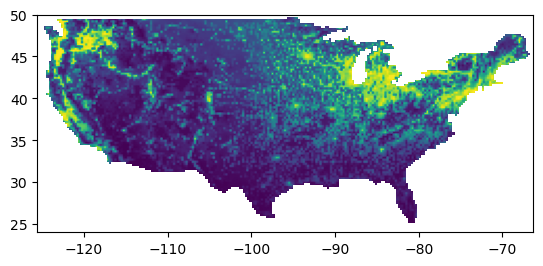

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.3999999521443642e+38, 'width': 237, 'height': 104, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.2500000000000006, 0.0, -125.54166666666688,
       0.0, -0.25000000000000006, 49.99999999999999), 'blockxsize': 237, 'blockysize': 8, 'tiled': False, 'interleave': 'band'}
./data/mosquitoes/culex_quinquefasciatus_raw_CONUS.tif


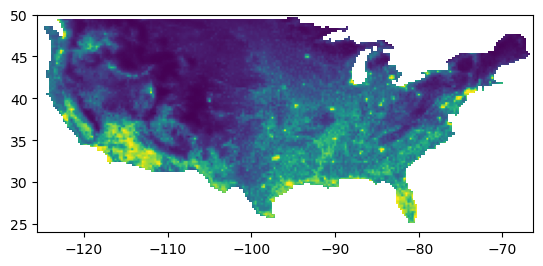

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.3999999521443642e+38, 'width': 237, 'height': 104, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.2500000000000005, 0.0, -125.54166666666691,
       0.0, -0.25, 50.0), 'blockxsize': 237, 'blockysize': 8, 'tiled': False, 'interleave': 'band'}


In [2]:
# Identical raster profiles for all urban culex vectors
pipiens_CONUS = './data/mosquitoes/culex_pipiens_raw_CONUS.tif'
#restuans_CONUS = './data/mosquitoes/culex_restuans_raw_CONUS.tif'
quinq_CONUS = './data/mosquitoes/culex_quinquefasciatus_raw_CONUS.tif'

#urban_culex = [pipiens_CONUS, restuans_CONUS, quinq_CONUS]
urban_culex = [pipiens_CONUS, quinq_CONUS]

# Plot out each raster and profile - all identical
for raster in urban_culex:
    with rasterio.open(raster) as src:
        print(raster)
        show(src)
        print(src.profile)

In [3]:
# Merge TWO culex rasters to retain the max cell values 
# https://automating-gis-processes.github.io/CSC18/lessons/L6/raster-mosaic.html

#urban_culex = [pipiens_CONUS, restuans_CONUS, quinq_CONUS]
urban_culex = [pipiens_CONUS, quinq_CONUS]

# List of rasters to merge
srcs = [rasterio.open(raster) for raster in urban_culex]

# Merge and retain max raster value
merged, out_trans = merge(srcs, method = 'max', resampling = Resampling.bilinear)

# Copy metadata from a src raster
meta = srcs[0].meta.copy()
nodata = srcs[0].nodata

# Update metadata
meta.update(
    dtype = rasterio.float32,
    count = 1,
    nodata = nodata
)

# Out raster fp
urban_culex_composite = './data/mosquitoes/urban_culex_composite_raw_CONUS_pip_quin.tif'

# Write out merged raster
with rasterio.open(urban_culex_composite, "w", **meta) as dst:
    dst.write(merged)

# Close all input rasters
for src in srcs:
    src.close()

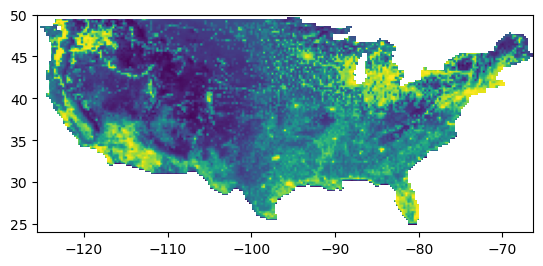

Profile: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.3999999521443642e+38, 'width': 237, 'height': 104, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.2500000000000006, 0.0, -125.54166666666688,
       0.0, -0.25000000000000006, 49.99999999999999), 'blockxsize': 237, 'blockysize': 8, 'tiled': False, 'interleave': 'band'}
Nodata: -3.3999999521443642e+38
CRS: EPSG:4326
Resolution (0.2500000000000006, 0.25000000000000006)
Min: 0.0021696246694773436
Max: 1.0
% nodata cells: 0.40960727036676403


In [4]:
urban_culex_composite = './data/mosquitoes/urban_culex_composite_raw_CONUS_pip_quin.tif'

with rasterio.open(urban_culex_composite) as src:
    show(src)
    print(f'Profile: {src.profile}')
    print(f'Nodata: {src.nodata}')
    print(f'CRS: {src.crs}')
    print(f'Resolution {src.res}')
   
    # Check min and max rescaled values:
    
    # Set initial global min and max
    global_min = np.inf 
    global_max = -np.inf 
    
    # Set total_nodata
    total_nodata = 0

    for ji, window in src.block_windows(1):
        data = src.read(1, window = window, masked = True)
        
        # Get local min and max for each window
        local_min = data.min()
        local_max = data.max()
        
        # Get global min and max by comparing the initial global min and max to each local min and max for all windows
        global_min = min(global_min, local_min) # Compares global_min to window min
        global_max = max(global_max, local_max) # Compared global_max to window max
        
        # Count nodata cells
        total_nodata += np.sum(data.mask)
        
    # Print the min and max rescaled values
    print(f'Min: {global_min}')
    print(f'Max: {global_max}')
    
    # % nodata cells
    total_cells = src.width * src.height
    percent_nodata = (total_nodata / total_cells) 
    print(f'% nodata cells: {percent_nodata}')